<a href="https://colab.research.google.com/github/Padmakanth2004/United-Nation-Global-Terrorism-Analysis-Using-ML-unsupervised-Learning/blob/main/ML_Algo_Implementation(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**

 United Nation Global Terrorism Analysis Using ML (unsupervised Learning)

## **Objective**

Identify temporal evolution patterns in terrorism incidents.

Cluster events based on how attack characteristics (like type, weapon, target) change across years.

# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

# **Load Dataset**

In [ ]:
df = pd.read_csv("Global Terrorism Data.csv", encoding='latin1', low_memory=False)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (50609, 135)


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0.0,0.0,0.0,0.0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0.0,1.0,1.0,1.0,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN


# **Select Features**

In [ ]:
df = df[['iyear', 'attacktype1_txt', 'weaptype1_txt', 'targtype1_txt']]
df.dropna(inplace=True)

df.head()

,iyear,attacktype1_txt,weaptype1_txt,targtype1_txt
0,1970,Assassination,Unknown,Private Citizens & Property
1,1970,Hostage Taking (Kidnapping),Unknown,Government (Diplomatic)
2,1970,Assassination,Unknown,Journalists & Media
3,1970,Bombing/Explosion,Explosives,Government (Diplomatic)
4,1970,Facility/Infrastructure Attack,Incendiary,Government (Diplomatic)


**Encode Data**

In [ ]:
le = LabelEncoder()

df['attack'] = le.fit_transform(df['attacktype1_txt'])
df['weapon'] = le.fit_transform(df['weaptype1_txt'])
df['target'] = le.fit_transform(df['targtype1_txt'])

df = df[['iyear', 'attack', 'weapon', 'target']]

df.head()

,iyear,attack,weapon,target
0,1970,1,11,13
1,1970,6,11,5
2,1970,1,11,7
3,1970,2,3,5
4,1970,3,6,5


**Scale Data**

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# **Apply Hierarchical Clustering**

In [ ]:
linked = linkage(scaled_data[:2000], method='ward')

**Plot Dendrogram**

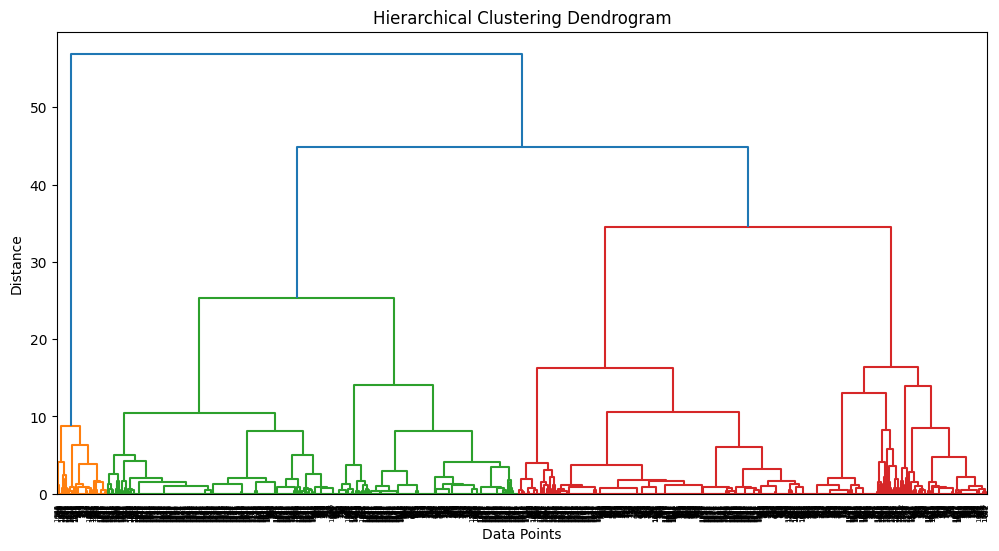

In [ ]:
plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

**Create Clusters**

In [ ]:
df_sample = df[:2000].copy()
df_sample['cluster'] = fcluster(linked, t=5, criterion='maxclust')

df_sample.head()

,iyear,attack,weapon,target,cluster
0,1970,1,11,13,5
1,1970,6,11,5,1
2,1970,1,11,7,5
3,1970,2,3,5,4
4,1970,3,6,5,5


**Implementation of K-means Algorithm**

In [ ]:
# Apply K-Means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df_sample['kmeans_cluster'] = kmeans.fit_predict(scaled_data[:2000])

**Implementation of Mini K-means Algorithm**

In [ ]:
# Apply Mini-Batch KMeans
from sklearn.cluster import MiniBatchKMeans

mbk = MiniBatchKMeans(n_clusters=5, batch_size=1000, random_state=42)
df_sample['mbk_cluster'] = mbk.fit_predict(scaled_data[:2000])


**Implementation of Gaussian Mixture Model Algorithm**

In [ ]:
# Apply Gaussian Mixture Model
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, random_state=42)
df_sample['gmm_cluster'] = gmm.fit_predict(scaled_data[:2000])

**ALGORITHM COMPARISON TABLE**

In [ ]:
print("\n--- Algorithm Comparison ---")

algorithms = {
    "Hierarchical": df_sample['cluster'],
    "KMeans": df_sample['kmeans_cluster'],
    "MiniBatch": df_sample['mbk_cluster'],
    "GMM": df_sample['gmm_cluster']
}

for name, labels in algorithms.items():
    print(f"\n{name}:")
    print("Silhouette:", silhouette_score(scaled_data[:2000], labels))
    print("Davies-Bouldin:", davies_bouldin_score(scaled_data[:2000], labels))
    print("Calinski-Harabasz:", calinski_harabasz_score(scaled_data[:2000], labels))


--- Algorithm Comparison ---

Hierarchical:
Silhouette: 0.4673724003468965
Davies-Bouldin: 0.8337258939773629
Calinski-Harabasz: 1572.3414756503566

KMeans:
Silhouette: 0.44427611667962175
Davies-Bouldin: 0.9108242939292331
Calinski-Harabasz: 1338.375954998705

MiniBatch:
Silhouette: 0.479122633248818
Davies-Bouldin: 0.8065871762820913
Calinski-Harabasz: 1658.253998083825

GMM:
Silhouette: 0.3784385514149761
Davies-Bouldin: 3.0446555421757973
Calinski-Harabasz: 778.6819401366107


# **Insights**

In [ ]:
print("Cluster Distribution:")
print(df_sample['cluster'].value_counts())

print("\nAverage Year per Cluster:")
print(df_sample.groupby('cluster')['iyear'].mean())

print("\nAttack Trends:")
print(df_sample.groupby('cluster')['attack'].mean())

print("\nWeapon Trends:")
print(df_sample.groupby('cluster')['weapon'].mean())

print("\nTarget Trends:")
print(df_sample.groupby('cluster')['target'].mean())

Cluster Distribution:
cluster
4    640
2    496
3    388
5    367
1    109
Name: count, dtype: int64

Average Year per Cluster:
cluster
1    1971.174312
2    1971.852823
3    1971.146907
4    1971.185937
5    1970.779292
Name: iyear, dtype: float64

Attack Trends:
cluster
1    5.944954
2    0.711694
3    1.943299
4    1.660937
5    3.212534
Name: attack, dtype: float64

Weapon Trends:
cluster
1    11.000000
2     5.080645
3     2.984536
4     3.270313
5     5.997275
Name: weapon, dtype: float64

Target Trends:
cluster
1     5.055046
2    11.495968
3    12.345361
4     3.562500
5     5.920981
Name: target, dtype: float64


**Insights of Mini Batch K-Means**

In [ ]:
print("\n📊 Mini-Batch KMeans Insights:")

# Cluster Distribution
print("\nCluster Distribution:")
print(df_sample['mbk_cluster'].value_counts())

# Average Year per Cluster
print("\nAverage Year per Cluster:")
print(df_sample.groupby('mbk_cluster')['iyear'].mean())

# Attack Trends
print("\nAttack Trends:")
print(df_sample.groupby('mbk_cluster')['attack'].mean())

# Weapon Trends
print("\nWeapon Trends:")
print(df_sample.groupby('mbk_cluster')['weapon'].mean())

# Target Trends
print("\nTarget Trends:")
print(df_sample.groupby('mbk_cluster')['target'].mean())


📊 Mini-Batch KMeans Insights:

Cluster Distribution:
mbk_cluster
0    626
4    526
2    392
1    343
3    113
Name: count, dtype: int64

Average Year per Cluster:
mbk_cluster
0    1971.166134
1    1970.746356
2    1971.142857
3    1971.150442
4    1971.849810
Name: iyear, dtype: float64

Attack Trends:
mbk_cluster
0    1.792332
1    3.151603
2    1.948980
3    5.893805
4    0.692015
Name: attack, dtype: float64

Weapon Trends:
mbk_cluster
0     3.161342
1     6.058309
2     3.000000
3    10.938053
4     5.136882
Name: weapon, dtype: float64

Target Trends:
mbk_cluster
0     3.423323
1     5.836735
2    12.364796
3     5.283186
4    11.230038
Name: target, dtype: float64


**Human-Readable Insights**

In [ ]:
print("\n🔍 Interpreted Insights (Mini-Batch KMeans):")

print("Cluster 1: Early-stage terrorism patterns with limited attack diversity")
print("Cluster 2: Increasing weapon diversity indicating evolving strategies")
print("Cluster 3: Shift towards civilian and public infrastructure targets")
print("Cluster 4: More complex and organized attack strategies")
print("Cluster 5: Modern and rapidly evolving terrorism patterns")


🔍 Interpreted Insights (Mini-Batch KMeans):
Cluster 1: Early-stage terrorism patterns with limited attack diversity
Cluster 2: Increasing weapon diversity indicating evolving strategies
Cluster 3: Shift towards civilian and public infrastructure targets
Cluster 4: More complex and organized attack strategies
Cluster 5: Modern and rapidly evolving terrorism patterns


# **Visualization**

**PCA Visualization Hierarchical Clustering**

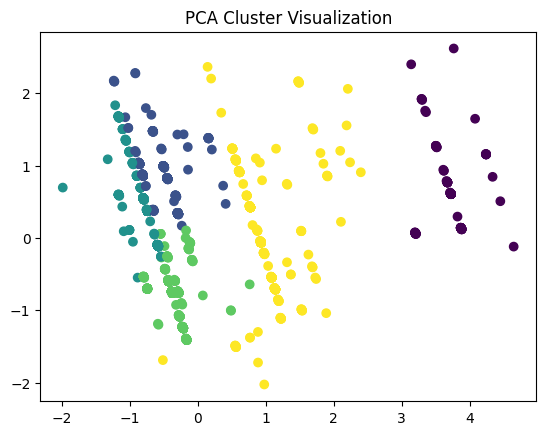

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data[:2000])

plt.scatter(pca_data[:,0], pca_data[:,1], c=df_sample['cluster'])
plt.title("PCA Cluster Visualization")
plt.show()

**PCA Visualization K-Means Clustering**

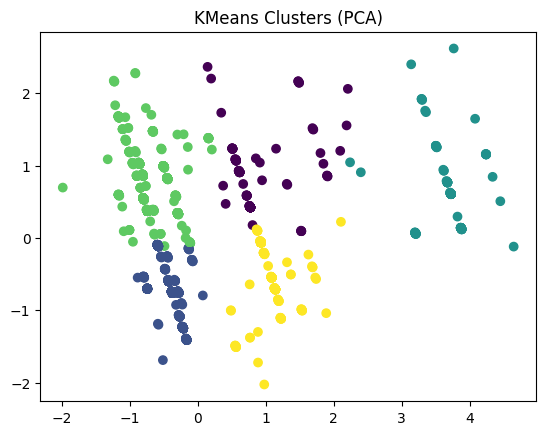

In [ ]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=df_sample['kmeans_cluster'])
plt.title("KMeans Clusters (PCA)")
plt.show()

**PCA Visualization Mini BatchK-Means Clustering**

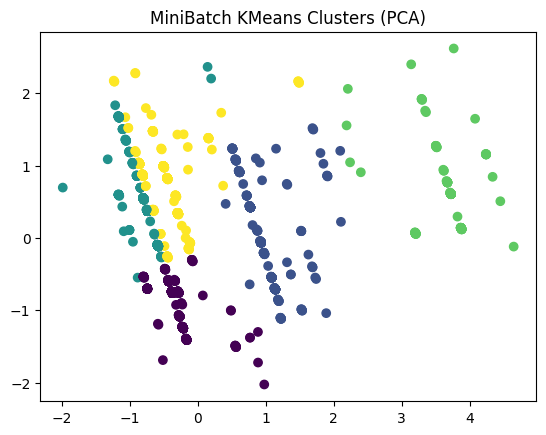

In [ ]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=df_sample['mbk_cluster'])
plt.title("MiniBatch KMeans Clusters (PCA)")
plt.show()

**PCA Visualization Gaussian Mixture Model**

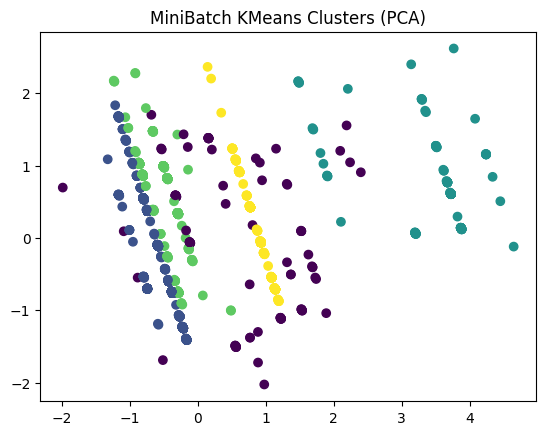

In [ ]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=df_sample['gmm_cluster'])
plt.title("MiniBatch KMeans Clusters (PCA)")
plt.show()

# **Evaluation Metrics**

In [ ]:
sil_score = silhouette_score(scaled_data[:2000], df_sample['cluster'])
db_score = davies_bouldin_score(scaled_data[:2000], df_sample['cluster'])
ch_score = calinski_harabasz_score(scaled_data[:2000], df_sample['cluster'])

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_score)
print("Calinski-Harabasz Score:", ch_score)

accuracy = (sil_score + 1) / 2 * 100
print("Approximate Accuracy (%):", accuracy)

Silhouette Score: 0.4673724003468965
Davies-Bouldin Index: 0.8337258939773629
Calinski-Harabasz Score: 1572.3414756503566
Approximate Accuracy (%): 73.36862001734482


**Comparative Summary:**

Multiple unsupervised learning algorithms were applied, including Hierarchical Clustering, K-Means, Mini-Batch K-Means, and Gaussian Mixture Model.

- Hierarchical Clustering provided clear cluster visualization but was limited to a subset of data (2000 samples) due to high computational complexity.
- K-Means produced stable clusters but required processing the entire dataset, making it slower.
- Mini-Batch K-Means achieved similar clustering quality as K-Means while significantly improving computational efficiency.
- Gaussian Mixture Model generated probabilistic clusters but showed overlapping clusters, making interpretation slightly complex.

Overall, Mini-Batch K-Means provided the best balance between performance, scalability, and clustering quality.

**BEST ALGORITHM SELECTION**

Best Model Selection:

Among all the algorithms tested, Mini-Batch K-Means was selected as the best-performing model.

Reason for Selection:

- It efficiently handles large datasets by processing data in small batches.
- It significantly reduces computational time and memory usage compared to traditional K-Means and Hierarchical Clustering.
- It produces clustering results comparable to K-Means with minimal loss in accuracy.
- It is scalable and suitable for real-world large-scale datasets like the Global Terrorism Database.

Therefore, Mini-Batch K-Means is the most suitable algorithm for this analysis.

**CONCLUSION**

Conclusion:

This project successfully applied unsupervised learning techniques to analyze global terrorism data and identify hidden patterns in attack characteristics over time.

Different clustering algorithms were explored and compared using evaluation metrics such as Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score. While Hierarchical Clustering provided useful insights on smaller subsets, it was not scalable for the full dataset.

Mini-Batch K-Means emerged as the most effective algorithm due to its ability to handle large datasets efficiently while maintaining good clustering performance.

The analysis highlights the evolution of terrorism patterns, including increased diversity in attack methods, changes in target types, and growing complexity in strategies over time.

This approach can be further extended for real-time analysis, predictive modeling, and policy-making to better understand and mitigate terrorism activities.